In [1]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import shap
import random
import os

import nltk
import nlpaug.augmenter.sentence as nas
import nlpaug.augmenter.word as naw
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from nlpaug.augmenter.word import BackTranslationAug

from gensim.models import KeyedVectors 

D:\Terminal\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
D:\Terminal\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
#load data
df = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Satria Data 2025\data\data_baru.csv")
df.head()

df_test = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Satria Data 2025\data\data_test.csv")
df_test.head()

,id,text,durasi,text_clean,normalisasi_teks
0,1.mp4,di sebelah saya sudah ada baik bj40 yang akan ...,0.59,di sebelah saya sudah ada baik bj yang akan ki...,di sebelah saya sudah ada baik bj yang akan ki...
1,2.mp4,Civic yang sudah dimodifikasi full carbon jadi...,1.33,civic yang sudah dimodifikasi full carbon jadi...,civic yang sudah dimodifikasi full carbon jadi...
2,3.mp4,nama tempat itu gua musang dan kita mampir sal...,1.06,nama tempat itu gua musang dan kita mampir sal...,nama tempat itu saya musang dan kita mampir sa...
3,4.mp4,bisa membuka Khazanah Khazanah nih bahasanya j...,2.00,bisa membuka khazanah khazanah nih bahasanya j...,bisa membuka khazanah khazanah ini bahasanya j...
4,5.mp4,HP 3 juta yang banyak gaya kotaknya aja nantan...,2.18,hp juta yang banyak gaya kotaknya aja nantang ...,hp juta yang banyak gaya kotaknya saja nantang...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               722 non-null    int64  
 1   text             722 non-null    object 
 2   durasi           722 non-null    float64
 3   emotion          722 non-null    object 
 4   text_cleaned     722 non-null    object 
 5   emotion_encoded  722 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 34.0+ KB


In [4]:
#Set Random seed untuk reprodusibilitas
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

In [5]:
#Case Folding & cleaning teks sederhana
def clean_text(text):
    text = str(text).lower()  # case folding
    text = re.sub(r"http\S+|www\S+", "", text)  # hapus URL
    text = re.sub(r"@\w+", "", text)  # hapus mention
    text = re.sub(r"#\w+", "", text)  # hapus hashtag
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # hapus angka & simbol
    text = re.sub(r"\s+", " ", text).strip()  # hapus spasi berlebih
    return text

df['text_cleaned'] = df['text_cleaned'].apply(clean_text) 

In [6]:
#Normalisasi Text
def load_kamus(file_path):
    kamus={}
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                slang = parts[0]
                normal = " ".join(parts[1:])
                kamus[slang] = normal
    return kamus

In [7]:
def normalisasi_teks(teks, kamus):
    words = teks.split()
    return " ".join([kamus.get(w, w) for w in words])

In [8]:
kamus = load_kamus(r"C:\Users\Aditya P J\Documents\Kuliah\Skripsi\Data\kbba.txt")
df['normalisasi_teks'] = df['text_cleaned'].apply(lambda x: normalisasi_teks(x, kamus))
df.head()

,id,text,durasi,emotion,text_cleaned,emotion_encoded,normalisasi_teks
0,103,kekuatan otot kaki kalian dengan cara duduk be...,0.57,Surprise,kekuatan otot kaki kalian dengan cara duduk be...,6,kekuatan otot kaki kalian dengan cara duduk be...
1,104,orang wajib yang perlu aku bawa pas lagi raket...,0.54,Sadness,orang wajib yang perlu aku bawa pas lagi raket...,5,orang wajib yang perlu aku bawa pas lagi raket...
2,106,nah Kemarin kan sudah ngasih tahu spill trick ...,1.05,Proud,nah kemarin kan sudah ngasih tahu spill trick ...,4,nah kemarin kan sudah memberikan tahu spill tr...
3,107,dibuat jadi alat pemersatu bangsa dan itu terb...,0.18,Surprise,dibuat jadi alat pemersatu bangsa dan itu terb...,6,dibuat jadi alat pemersatu bangsa dan itu terb...
4,109,lagi istirahat dulu udah 2 lap tinggal satu la...,0.42,Proud,lagi istirahat dulu udah lap tinggal satu lap ...,4,lagi istirahat dulu sudah lap tinggal satu lap...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                722 non-null    int64  
 1   text              722 non-null    object 
 2   durasi            722 non-null    float64
 3   emotion           722 non-null    object 
 4   text_cleaned      722 non-null    object 
 5   emotion_encoded   722 non-null    int64  
 6   normalisasi_teks  722 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 39.6+ KB


In [10]:
label_map = {
    "Anger": 0,
    "Fear": 1,
    "Joy": 2,
    "Neutral": 3,
    "Proud": 4,
    "Sadness": 5,
    "Surprise": 6,
    "Trust": 7
}

df['emotion_encoded'] = df['emotion'].map(label_map)

In [11]:
#Augmentasi dengan RandomWordAug 

# === Augmenter ===
aug = naw.RandomWordAug(action="substitute")  # ganti kata random

def safe_augment(text, num_aug=1):
    """Augmentasi dengan fallback duplikasi kalau gagal"""
    augmented = []
    for _ in range(num_aug):
        try:
            aug_text = aug.augment(text)
            if isinstance(aug_text, list):
                augmented.extend(aug_text)
            else:
                augmented.append(aug_text)
        except:
            # fallback → pakai teks asli
            augmented.append(text)
    return augmented

# === Target jumlah data per kelas ===
TARGET_PER_CLASS = 800  

df_balanced = df.copy()
augmented_texts = []
augmented_labels = []

for label, count in df['emotion'].value_counts().items():
    if count < TARGET_PER_CLASS:
        needed = TARGET_PER_CLASS - count
        print(f"Kelas {label} → butuh {needed} data tambahan")

        # sampling dengan replacement
        samples = df.loc[df['emotion'] == label, 'normalisasi_teks'].sample(
            needed, replace=True, random_state=42
        )

        for text in samples:
            new_texts = safe_augment(text, num_aug=1)  # augment sekali saja
            augmented_texts.extend(new_texts)
            augmented_labels.extend([label] * len(new_texts))

# === Buat DataFrame hasil augmentasi ===
df_aug = pd.DataFrame({
    "normalisasi_teks": augmented_texts,
    "emotion": augmented_labels
})

# === Gabungkan dengan data asli ===
df = pd.concat([df_balanced, df_aug], ignore_index=True)

# === Encode label ===
le = LabelEncoder()
df['emotion_encoded'] = le.fit_transform(df['emotion'])

print("\nDistribusi sesudah augmentasi:\n", df['emotion'].value_counts())
df.info()

Kelas Surprise → butuh 504 data tambahan
Kelas Trust → butuh 635 data tambahan
Kelas Proud → butuh 663 data tambahan
Kelas Joy → butuh 749 data tambahan
Kelas Anger → butuh 765 data tambahan
Kelas Sadness → butuh 783 data tambahan
Kelas Fear → butuh 785 data tambahan
Kelas Neutral → butuh 794 data tambahan

Distribusi sesudah augmentasi:
 emotion
Surprise    800
Sadness     800
Proud       800
Trust       800
Joy         800
Anger       800
Neutral     800
Fear        800
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                722 non-null    float64
 1   text              722 non-null    object 
 2   durasi            722 non-null    float64
 3   emotion           6400 non-null   object 
 4   text_cleaned      722 non-null    object 
 5   emotion_encoded   6400 non-null   int32  
 6   normalisas

In [12]:
# Split hanya train dan validasi
X_train, X_val, y_train, y_val = train_test_split(
    df['normalisasi_teks'], df['emotion_encoded'],
    test_size=0.2, stratify=df['emotion_encoded'], random_state=42
)

# Test data (hanya teks, tidak ada label)
X_test = df_test['normalisasi_teks']

In [13]:
#Tokenisasi world-level
MAX_VOCAB = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

In [16]:
ft = KeyedVectors.load_word2vec_format(r"D:\cc.id.300.vec", limit=50000)

embedding_dim = 300
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index)+1, embedding_dim))

for word, i in word_index.items():
    if word in ft:
        embedding_matrix[i] = ft[word]

In [14]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


In [18]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

param_grid = {
    "lstm_units": [64, 128],
    "dropout": [0.3, 0.4],
    "batch_size": [32, 64],
    "lr": [1e-3, 5e-4]
}

best_f1 = 0
best_params = None

for units in param_grid["lstm_units"]:
    for dr in param_grid["dropout"]:
        for bs in param_grid["batch_size"]:
            for lr in param_grid["lr"]:
                model = Sequential([
                    Embedding(input_dim=len(word_index)+1,
                              output_dim=300,
                              weights=[embedding_matrix],
                              input_length=MAX_LEN,
                              trainable=True),
                    Bidirectional(LSTM(units, dropout=dr, recurrent_dropout=dr, return_sequences=True)),
                    Conv1D(filters=128, kernel_size=3, activation="relu"),
                    GlobalMaxPooling1D(),
                    Dense(128, activation="relu"),
                    Dropout(0.4),
                    Dense(8, activation="softmax")
                ])
                opt = tf.keras.optimizers.Adam(learning_rate=lr)
                model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

model.build(input_shape=(None, MAX_LEN))
model.summary()

D:\Terminal\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)             │ (None, 100, 300)            │       3,075,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_15 (Bidirectional)     │ (None, 100, 256)            │         439,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_15 (Conv1D)                   │ (None, 98, 128)             │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_15              │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,630,872 (13.85 MB)

 Trainable params: 3,630,872 (13.85 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
mc = ModelCheckpoint('best_lstm.keras', monitor='val_accuracy', save_best_only=True)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 352ms/step - accuracy: 0.2108 - loss: 2.0182 - val_accuracy: 0.5244 - val_loss: 1.4072
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.5138 - loss: 1.2647 - val_accuracy: 0.7080 - val_loss: 0.6772
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 416ms/step - accuracy: 0.7230 - loss: 0.6950 - val_accuracy: 0.8105 - val_loss: 0.4361
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 393ms/step - accuracy: 0.8276 - loss: 0.4217 - val_accuracy: 0.9209 - val_loss: 0.2699
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 427ms/step - accuracy: 0.9081 - loss: 0.2535 - val_accuracy: 0.9453 - val_loss: 0.1730
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 408ms/step - accuracy: 0.9574 - loss: 0.1483 - val_accuracy: 0.9678 - val_loss: 0.1283
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 476ms/step - accuracy: 0.9764 - loss: 0.0810 - val_accuracy: 0.9746 - val_loss: 0.1122
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 434ms/step - accuracy: 0.9810 - loss: 0.0642 - val_accu

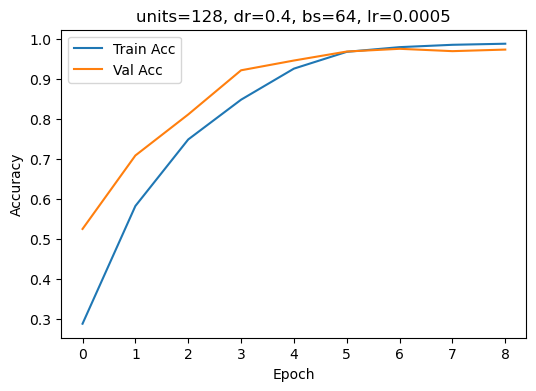

In [22]:
# Pastikan label jadi numpy array, index rapi
y_train = np.array(y_train)


history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=bs,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=1   # bisa ganti ke 1 kalau mau lihat live progress
)

# --- tampilkan hasil training terakhir ---
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.3f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.3f}")

# plot grafik training vs validation
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title(f"units={units}, dr={dr}, bs={bs}, lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
              precision    recall  f1-score   support

       Anger       0.99      1.00      1.00       146
        Fear       1.00      1.00      1.00       133
         Joy       0.99      1.00      0.99        87
     Neutral       1.00      1.00      1.00       121
       Proud       0.94      0.95      0.94       153
     Sadness       0.99      1.00      0.99       135
    Surprise       0.95      0.90      0.92       119
       Trust       0.95      0.95      0.95       130

    accuracy                           0.97      1024
   macro avg       0.98      0.97      0.98      1024
weighted avg       0.97      0.97      0.97      1024



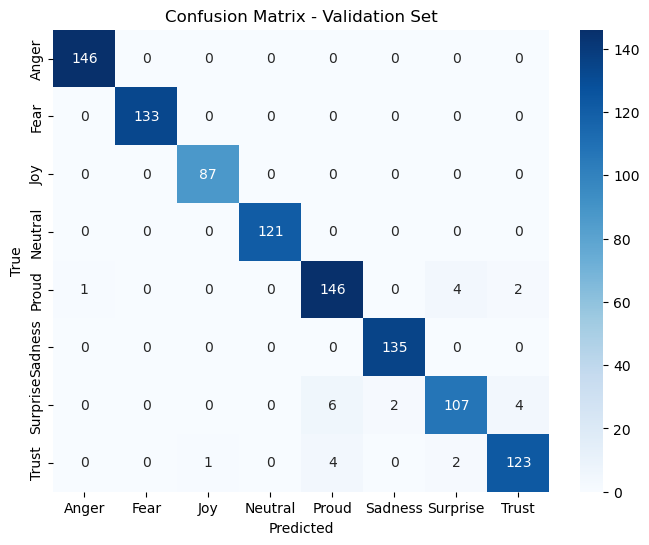

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ambil data validasi dari history (20% terakhir dari X_train_pad dan y_train)
val_split = int(0.8 * len(X_train_pad))
X_val = X_train_pad[val_split:]
y_val = y_train[val_split:]

# Prediksi di validation set
y_val_pred = model.predict(X_val).argmax(axis=1)

# Laporan detail (precision, recall, f1 per label)
print(classification_report(y_val, y_val_pred, target_names=list(label_map.values())))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Validation Set")
plt.show()


In [32]:
# Prediksi
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

y_test_pred = model.predict(X_test_pad).argmax(axis=1)

# Mapping label sesuai ketentuan panitia
label_map = {
    0: "Proud",
    1: "Trust",
    2: "Joy",
    3: "Surprise",
    4: "Neutral",
    5: "Sadness",
    6: "Fear",
    7: "Anger"
}

# Kalau diminta numerik → langsung pakai y_test_pred (tanpa mapping ke string)
df_submit = pd.DataFrame({
    "id": range(1, len(y_test_pred)+1),
    "predicted": y_test_pred   # langsung numerik sesuai aturan panitia
})

# Simpan ke CSV standar (pemisah koma, tanpa index)
df_submit.to_csv("submission_Latte2025.csv", index=False)

print(df_submit.head())


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
   id  predicted
0   1          6
1   2          4
2   3          6
3   4          6
4   5          6
